# **Phase 2: Analytical Basis Harmonization**
---
**Focus:** Only on instrinsic properties of fuel and avoiding system based moisture effects.

**Research question:** Which analytical basis best representsthe quality of fuel energy
in thermochemical systems to compare biomass, and how to control multi basis variabe without losing information?

In [1]:
import pandas as pd

# load validated data
df = pd.read_csv("../data/interim/validated_data.csv")
df.head()

,Sample_ID,Short_Description,Biomass_Type,Class,Subclass,State,Location_Notes,Link_Ref,Source,Full_Description,...,Mn3O4,Fe2O3,Other,File_Name_Ref,Extension,Data_Sources,SSC_NAME16,STE_NAME16,Longitude,Latitude
0,1,Radiata pine chips,Industrial Processing,Timber industry,Woodchips (Softwood),NSW,Hunter Valley,1,B2,Radiata pine chips,...,0.91,3.63,31.24,1.0,JPG,NaN,Hunter Valley,New South Wales,151.700600,-32.193200
1,3,Dynamic lifter pellets (from chicken manure),Agricultural,Animal farming,Chicken manure pellets,NSW,NSW,3,B36,Yates dynamic lifter pellets (garden product d...,...,0.26,1.90,5.63,18.0,JPG,NaN,New South Wales,New South Wales,NaN,NaN
2,4,Biosolids,Urban Waste,Biosolids,Treated biosolids,NSW,Quakers Hill,4,B3,Biosolids (Sewerage Sludge - dried 110C),...,0.15,25.70,10.33,22.0,JPG,NaN,Quakers Hill,New South Wales,150.888979,-33.728392
3,5,Paper sludge,Industrial Processing,Paper industry,Paper sludge,NSW,AMCOR,5,B4,Paper sludge (dried at 105C),...,0.03,2.06,18.01,26.0,JPG,NaN,AMCOR,New South Wales,NaN,NaN
4,6,Cotton seed hulls,Industrial Processing,Cotton Industry,Cotton seed hulls,NSW,Narrabri,6,B5,Cotton seed hulls,...,0.07,0.91,42.97,30.0,JPG,NaN,Narrabri,New South Wales,149.770999,-30.219856


In [ ]:
# identify multi-basis columns 
basis_groups = {
    "Moisture": ["Moist_ar", "Moist_ad"],
    "Ash": ["Ash_ar", "Ash_ad", "Ash_db"],
    "VM": ["VM_ar", "VM_ad", "VM_db", "VM_daf"],
    "FC": ["FC_ar", "FC_ad", "FC_db", "FC_daf"],
    "HHV": [
        "CV_MJ/kg_ar", "CV_MJ/kg_ad",               # lab reported CV kcal/kg unit is ignored, to focus only on HHV standard unit 'MJ'
        "CV_MJ/kg_db", "CV_MJ/kg_daf"               
        ],
}

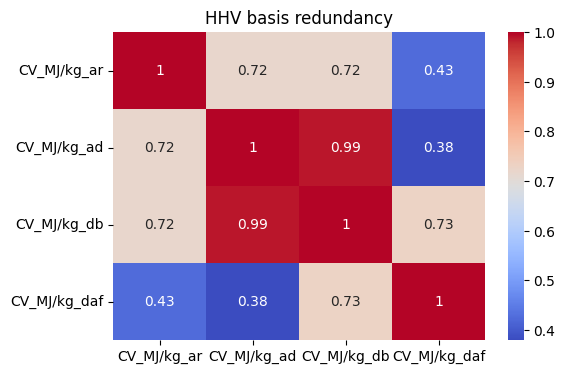

In [3]:
# checking redundancy through correlation          
import seaborn as sns
import matplotlib.pyplot as plt                     

hhv_df = df[basis_groups["HHV"]]
corr = hhv_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("HHV basis redundancy")
plt.show()

**Interpreting the HHV basis correlation matrix**

* `CV_ad` vs `CV_db` : almost identical information, so one base is retained
* `CV_ar` vs (`CV_ad`, `CV_db`) : `ar` have system based moisture variance which is not an intrinsic fuel property, so excluded
* `CV_daf` vs others : `daf` removes both moisture and ash, and ash is an instrinsic fuel property, so excluded

**Decision:** dry basis (`db`) is selected as the canonical analytical basis because it contains intrinsic fuel chemistry and retains ash content without moisture driven changes.

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))          

from src.data.harmonize_basis import harmonize_to_db_basis

df = pd.read_csv("../data/interim/validated_data.csv")              # copy of raw dataset

harmonized_df = harmonize_to_db_basis(
    df,
    output_csv="../data/interim/harmonized_db_basis.csv",
    meta_path="../data/metadata/basis_selection.json"
)